# Compute carbonate sensitivity from monthly CESM-MARBL output

In [1]:
import xarray as xr

In [2]:
prefix = "/global/cfs/projectdirs/m4746/Datasets/Ocean-CDR-Atlas-v0/OAE-Efficiency-Map/research-grade-compressed/control/g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h"

In [3]:
suffix = "030601-036812.nc"

In [4]:
d = {
    "temp": "TEMP",
    "salt": "SALT",
    "ALK": "ALK",
    "DIC": "DIC",
    "PO4": "PO4",
    "SiO3": "SiO3"
}

In [5]:
ds = xr.Dataset()

In [6]:
for key, value in d.items():
    ds0 = xr.open_dataset(f"{prefix}.{value}.{suffix}", decode_timedelta=False)
    da0 = ds0[value]
    ds[key] = da0

In [7]:
ds = ds.isel(time=slice(480, 492+12*22))

In [8]:
ds

<xarray.Dataset> Size: 49GB
Dimensions:  (z_t: 60, nlat: 384, nlon: 320, time: 276)
Coordinates:
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
    ULONG    (nlat, nlon) float64 983kB ...
    ULAT     (nlat, nlon) float64 983kB ...
    TLONG    (nlat, nlon) float64 983kB ...
    TLAT     (nlat, nlon) float64 983kB ...
  * time     (time) object 2kB 0346-02-01 00:00:00 ... 0369-01-01 00:00:00
Dimensions without coordinates: nlat, nlon
Data variables:
    temp     (time, z_t, nlat, nlon) float32 8GB ...
    salt     (time, z_t, nlat, nlon) float32 8GB ...
    ALK      (time, z_t, nlat, nlon) float32 8GB ...
    DIC      (time, z_t, nlat, nlon) float32 8GB ...
    PO4      (time, z_t, nlat, nlon) float32 8GB ...
    SiO3     (time, z_t, nlat, nlon) float32 8GB ...

### Sanity check

In [9]:
base_path = "/global/cfs/projectdirs/m4746/Datasets/Ocean-CDR-Atlas-v0/DOR-Efficiency-Map/research-grade-compressed/"

In [10]:
polygon_id = "000"

In [11]:
intervention_month = "01"
intervention_year = "1999"
year = "0347"

In [12]:
path = f"{base_path}/{polygon_id}/{intervention_month}/smyle.cdr-atlas-v0.glb-dor.{polygon_id}-{intervention_year}-{intervention_month}.pop.h.{year}-**.nc"

In [13]:
ds0 = xr.open_mfdataset(path, decode_timedelta=False)

In [14]:
ds0

<xarray.Dataset> Size: 6GB
Dimensions:                     (polygon_id: 1, injection_date: 1,
                                 elapsed_time: 12, z_t: 60, nlat: 384,
                                 nlon: 320, z_t_150m: 15, z_w: 60, z_w_top: 60,
                                 z_w_bot: 60)
Coordinates: (12/63)
  * z_t                         (z_t) float32 240B 500.0 1.5e+03 ... 5.375e+05
  * z_t_150m                    (z_t_150m) float32 60B 500.0 ... 1.45e+04
  * z_w                         (z_w) float32 240B 0.0 1e+03 ... 5e+05 5.25e+05
  * z_w_top                     (z_w_top) float32 240B 0.0 1e+03 ... 5.25e+05
  * z_w_bot                     (z_w_bot) float32 240B 1e+03 2e+03 ... 5.5e+05
    dz                          (z_t) float32 240B dask.array<chunksize=(60,), meta=np.ndarray>
    ...                          ...
    nsurface_t                  float64 8B 8.61e+04
    nsurface_u                  float64 8B 8.297e+04
    area_m2                     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
  * polygon_id                  (polygon_id) int32 4B 0
  * injection_date              (injection_date) object 8B 1999-01-01 00:00:00
  * elapsed_time                (elapsed_time) int64 96B 0 31 59 ... 273 304 334
Dimensions without coordinates: nlat, nlon
Data variables: (12/46)
    CO3                         (polygon_id, injection_date, elapsed_time, z_t, nlat, nlon) float32 354MB dask.array<chunksize=(1, 1, 1, 60, 384, 320), meta=np.ndarray>
    HCO3                        (polygon_id, injection_date, elapsed_time, z_t, nlat, nlon) float32 354MB dask.array<chunksize=(1, 1, 1, 60, 384, 320), meta=np.ndarray>
    H2CO3                       (polygon_id, injection_date, elapsed_time, z_t, nlat, nlon) float32 354MB dask.array<chunksize=(1, 1, 1, 60, 384, 320), meta=np.ndarray>
    pH_3D                       (polygon_id, injection_date, elapsed_time, z_t, nlat, nlon) float32 354MB dask.array<chunksize=(1, 1, 1, 60, 384, 320), meta=np.ndarray>
    CO3_ALT_CO2                 (polygon_id, injection_date, elapsed_time, z_t, nlat, nlon) float32 354MB dask.array<chunksize=(1, 1, 1, 60, 384, 320), meta=np.ndarray>
    pH_3D_ALT_CO2               (polygon_id, injection_date, elapsed_time, z_t, nlat, nlon) float32 354MB dask.array<chunksize=(1, 1, 1, 60, 384, 320), meta=np.ndarray>
    ...                          ...
    STF_ALK_ALT_CO2             (polygon_id, injection_date, elapsed_time, nlat, nlon) float32 6MB dask.array<chunksize=(1, 1, 1, 384, 320), meta=np.ndarray>
    IAGE                        (polygon_id, injection_date, elapsed_time, z_t, nlat, nlon) float32 354MB dask.array<chunksize=(1, 1, 1, 60, 384, 320), meta=np.ndarray>
    tend_zint_100m_DIC          (polygon_id, injection_date, elapsed_time, nlat, nlon) float32 6MB dask.array<chunksize=(1, 1, 1, 384, 320), meta=np.ndarray>
    tend_zint_100m_DIC_ALT_CO2  (polygon_id, injection_date, elapsed_time, nlat, nlon) float32 6MB dask.array<chunksize=(1, 1, 1, 384, 320), meta=np.ndarray>
    tend_zint_100m_ALK          (polygon_id, injection_date, elapsed_time, nlat, nlon) float32 6MB dask.array<chunksize=(1, 1, 1, 384, 320), meta=np.ndarray>
    tend_zint_100m_ALK_ALT_CO2  (polygon_id, injection_date, elapsed_time, nlat, nlon) float32 6MB dask.array<chunksize=(1, 1, 1, 384, 320), meta=np.ndarray>
Attributes:
    title:             smyle.cdr-atlas-v0.glb-dor_North_Atlantic_basin_000_19...
    history:           none
    Conventions:       CF-1.0; http://www.cgd.ucar.edu/cms/eaton/netcdf/CF-cu...
    time_period_freq:  month_1
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    contents:          Diagnostic and Prognostic Variables
    source:            CCSM POP2, the CCSM Ocean Component
    revision:          $Id$
    calendar:          All years have exactly  365 days.
    start_time:        This dataset was created on 2024-11-04 at 21:08:03.3
    cell_methods:      cell_methods = time: mean ==> the variable values are ...

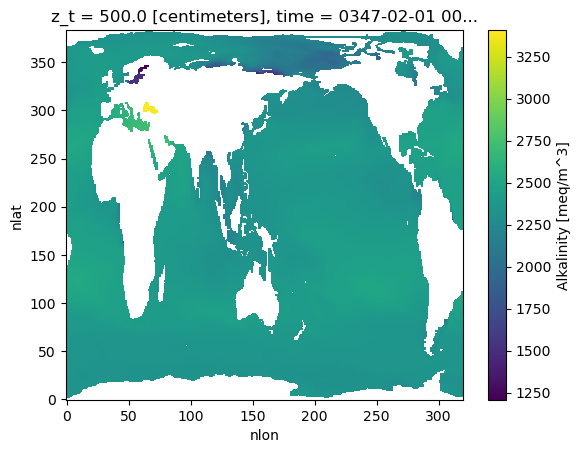

In [15]:
ds["ALK"].isel(time=12, z_t=0).plot()

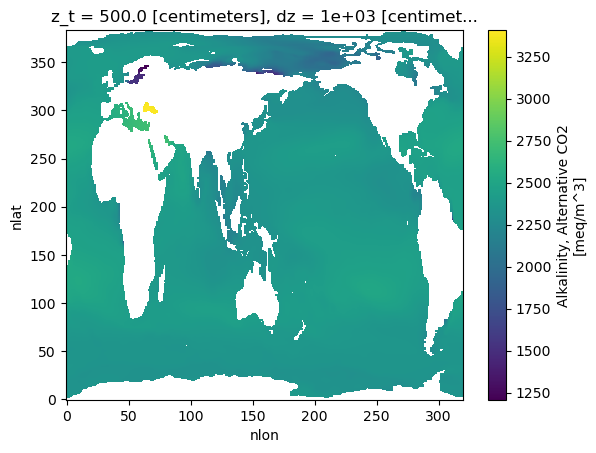

In [16]:
ds0["ALK_ALT_CO2"].isel(elapsed_time=0, z_t=0).plot()

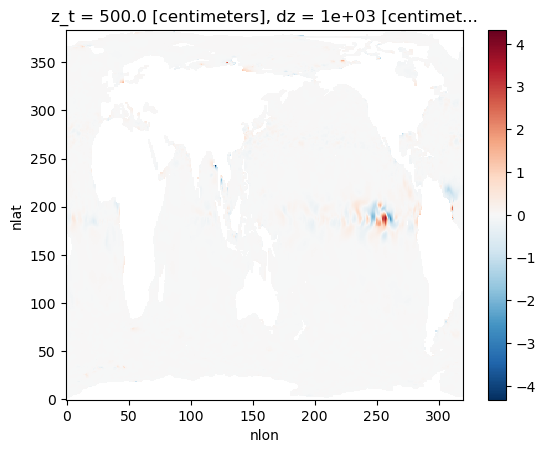

In [17]:
(ds0["ALK_ALT_CO2"].isel(elapsed_time=10, z_t=0) - ds["ALK"].isel(time=10+12, z_t=0)).plot()

### Compute carbonate sensitivity

In [18]:
ds = ds.isel(z_t=0)

In [19]:
ds

<xarray.Dataset> Size: 818MB
Dimensions:  (nlat: 384, nlon: 320, time: 276)
Coordinates:
    z_t      float32 4B 500.0
    ULONG    (nlat, nlon) float64 983kB ...
    ULAT     (nlat, nlon) float64 983kB ...
    TLONG    (nlat, nlon) float64 983kB ...
    TLAT     (nlat, nlon) float64 983kB ...
  * time     (time) object 2kB 0346-02-01 00:00:00 ... 0369-01-01 00:00:00
Dimensions without coordinates: nlat, nlon
Data variables:
    temp     (time, nlat, nlon) float32 136MB ...
    salt     (time, nlat, nlon) float32 136MB ...
    ALK      (time, nlat, nlon) float32 136MB ...
    DIC      (time, nlat, nlon) float32 136MB ...
    PO4      (time, nlat, nlon) float32 136MB ...
    SiO3     (time, nlat, nlon) float32 136MB ...

In [20]:
ds.time

<xarray.DataArray 'time' (time: 276)> Size: 2kB
array([cftime.DatetimeNoLeap(346, 2, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(346, 3, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(346, 4, 1, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(368, 11, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(368, 12, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(369, 1, 1, 0, 0, 0, 0, has_year_zero=True)],
      shape=(276,), dtype=object)
Coordinates:
    z_t      float32 4B 500.0
  * time     (time) object 2kB 0346-02-01 00:00:00 ... 0369-01-01 00:00:00
Attributes:
    long_name:     time
    bounds:        time_bound
    cell_methods:  time: mean

In [21]:
import PyCO2SYS as pyco2

In [22]:
def compute_dDICdCO2(ds):

    csys = pyco2.sys(
        par1 = ds.ALK * 1000 / 1025, # μmol·kg−1
        par2 = ds.DIC * 1000 / 1025, # μmol·kg−1
        par1_type = 1,
        par2_type = 2,
        salinity = ds.salt,
        temperature = ds.temp,
        total_silicate = ds.SiO3 * 1000 / 1025, # μmol·kg−1
        total_phosphate = ds.PO4 * 1000 / 1025 # μmol·kg−1
    )
    return (csys["dic"] - (csys["HCO3"] + 2 * csys["CO3"]) / csys["isocapnic_quotient"]) / csys["CO2"]


In [23]:
dDICdCO2 = compute_dDICdCO2(ds)

In [24]:
ds_carbonate_sensitivity = xr.Dataset({
    "dDICdCO2": xr.DataArray(dDICdCO2, dims=["time", "nlat", "nlon"]),
})

In [25]:
ds_carbonate_sensitivity

<xarray.Dataset> Size: 271MB
Dimensions:   (time: 276, nlat: 384, nlon: 320)
Dimensions without coordinates: time, nlat, nlon
Data variables:
    dDICdCO2  (time, nlat, nlon) float64 271MB nan nan nan nan ... nan nan nan

### Create coordinates like alk forcing

In [26]:
ds_ref = xr.open_dataset("/global/cfs/projectdirs/m4746/Projects/OAE-Efficiency-Map/data/alk-forcing/OAE-Efficiency-Map/alk-forcing-North_Atlantic_basin.000-1999-01.nc")

In [28]:
ds_ref

<xarray.Dataset> Size: 4GB
Dimensions:      (Y: 384, X: 320, time: 7665, d2: 2)
Coordinates:
    TLAT         (Y, X) float64 983kB ...
    TLONG        (Y, X) float64 983kB ...
  * X            (X) int32 1kB 1 2 3 4 5 6 7 8 ... 314 315 316 317 318 319 320
  * Y            (Y) int32 2kB 1 2 3 4 5 6 7 8 ... 378 379 380 381 382 383 384
  * time         (time) object 61kB 1999-01-01 12:00:00 ... 2019-12-31 12:00:00
Dimensions without coordinates: d2
Data variables:
    KMT          (Y, X) int32 492kB ...
    TAREA        (Y, X) float32 492kB ...
    alk_forcing  (time, Y, X) float32 4GB ...
    time_bnds    (time, d2) object 123kB ...
Attributes:
    history:  Wed Nov 15 08:57:04 2023: ncks -O --fl_fmt=64bit /glade/scratch...
    NCO:      netCDF Operators version 5.1.6 (Homepage = http://nco.sf.net, C...

In [29]:
ds_carbonate_sensitivity = ds_carbonate_sensitivity.swap_dims({"nlat": "Y", "nlon": "X"})

In [34]:
ds_carbonate_sensitivity["Y"] = ds_ref["Y"]
ds_carbonate_sensitivity["X"] = ds_ref["X"]

In [48]:
ds_carbonate_sensitivity = ds_carbonate_sensitivity.assign_coords(
    TLAT=ds_ref["TLAT"]
)
ds_carbonate_sensitivity = ds_carbonate_sensitivity.assign_coords(
    TLONG=ds_ref["TLONG"]
)

In [49]:
ds_carbonate_sensitivity

<xarray.Dataset> Size: 273MB
Dimensions:   (time: 276, Y: 384, X: 320)
Coordinates:
  * Y         (Y) int32 2kB 1 2 3 4 5 6 7 8 ... 377 378 379 380 381 382 383 384
  * X         (X) int32 1kB 1 2 3 4 5 6 7 8 ... 313 314 315 316 317 318 319 320
    TLAT      (Y, X) float64 983kB ...
    TLONG     (Y, X) float64 983kB ...
Dimensions without coordinates: time
Data variables:
    dDICdCO2  (time, Y, X) float64 271MB nan nan nan nan nan ... nan nan nan nan

In [50]:
ds_ref.time

<xarray.DataArray 'time' (time: 7665)> Size: 61kB
array([cftime.DatetimeNoLeap(1999, 1, 1, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1999, 1, 2, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1999, 1, 3, 12, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2019, 12, 29, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2019, 12, 30, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2019, 12, 31, 12, 0, 0, 0, has_year_zero=True)],
      shape=(7665,), dtype=object)
Coordinates:
  * time     (time) object 61kB 1999-01-01 12:00:00 ... 2019-12-31 12:00:00
Attributes:
    bounds:   time_bnds

In [51]:
ds_ref.time_bnds.values

array([[cftime.DatetimeNoLeap(1999, 1, 1, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(1999, 1, 2, 0, 0, 0, 0, has_year_zero=True)],
       [cftime.DatetimeNoLeap(1999, 1, 2, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(1999, 1, 3, 0, 0, 0, 0, has_year_zero=True)],
       [cftime.DatetimeNoLeap(1999, 1, 3, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(1999, 1, 4, 0, 0, 0, 0, has_year_zero=True)],
       ...,
       [cftime.DatetimeNoLeap(2019, 12, 29, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(2019, 12, 30, 0, 0, 0, 0, has_year_zero=True)],
       [cftime.DatetimeNoLeap(2019, 12, 30, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(2019, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
       [cftime.DatetimeNoLeap(2019, 12, 31, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(2020, 1, 1, 0, 0, 0, 0, has_year_zero=True)]],
      shape=(7665, 2), dtype=object)

In [52]:
import numpy as np
import cftime

In [53]:
start_year = 1998
n_months = len(ds_carbonate_sensitivity.time)
n_years = n_months // 12
years = np.arange(start_year, start_year + n_years)

In [54]:
n_years

23

In [55]:
days_in_month = np.array([31,28,31,30,31,30,31,31,30,31,30,31])

daily_times = [
    cftime.DatetimeNoLeap(y, m, d, 12, 0, 0)
    for y in years
    for m in range(1, 13)
    for d in range(1, days_in_month[m - 1] + 1)
]
daily_times = np.array(daily_times)
print(f"Total daily timestamps: {len(daily_times)}")

Total daily timestamps: 8395


In [67]:
daily_times

array([cftime.DatetimeNoLeap(1998, 1, 1, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1998, 1, 2, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1998, 1, 3, 12, 0, 0, 0, has_year_zero=True),
       ...,
       cftime.DatetimeNoLeap(2020, 12, 29, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2020, 12, 30, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2020, 12, 31, 12, 0, 0, 0, has_year_zero=True)],
      shape=(8395,), dtype=object)

In [69]:
from datetime import timedelta
half_day = timedelta(hours=12)
time_bnds = np.array([
    [t - half_day, t + half_day] for t in daily_times
])

In [70]:
time_bnds

array([[cftime.DatetimeNoLeap(1998, 1, 1, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(1998, 1, 2, 0, 0, 0, 0, has_year_zero=True)],
       [cftime.DatetimeNoLeap(1998, 1, 2, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(1998, 1, 3, 0, 0, 0, 0, has_year_zero=True)],
       [cftime.DatetimeNoLeap(1998, 1, 3, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(1998, 1, 4, 0, 0, 0, 0, has_year_zero=True)],
       ...,
       [cftime.DatetimeNoLeap(2020, 12, 29, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(2020, 12, 30, 0, 0, 0, 0, has_year_zero=True)],
       [cftime.DatetimeNoLeap(2020, 12, 30, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(2020, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
       [cftime.DatetimeNoLeap(2020, 12, 31, 0, 0, 0, 0, has_year_zero=True),
        cftime.DatetimeNoLeap(2021, 1, 1, 0, 0, 0, 0, has_year_zero=True)]],
      shape=(8395, 2), dtype=object)

In [56]:
repeat_counts = np.tile(days_in_month, n_years)

In [57]:
expanded = ds_carbonate_sensitivity.isel(
    time=np.repeat(np.arange(n_months), repeat_counts)
)

In [58]:
expanded

<xarray.Dataset> Size: 8GB
Dimensions:   (time: 8395, Y: 384, X: 320)
Coordinates:
  * Y         (Y) int32 2kB 1 2 3 4 5 6 7 8 ... 377 378 379 380 381 382 383 384
  * X         (X) int32 1kB 1 2 3 4 5 6 7 8 ... 313 314 315 316 317 318 319 320
    TLAT      (Y, X) float64 983kB ...
    TLONG     (Y, X) float64 983kB ...
Dimensions without coordinates: time
Data variables:
    dDICdCO2  (time, Y, X) float64 8GB nan nan nan nan nan ... nan nan nan nan

In [71]:
expanded = expanded.assign_coords(
    time=("time", daily_times),
    time_bnds=(("time", "d2"), time_bnds)
)

In [72]:
expanded

<xarray.Dataset> Size: 8GB
Dimensions:    (time: 8395, Y: 384, X: 320, d2: 2)
Coordinates:
  * Y          (Y) int32 2kB 1 2 3 4 5 6 7 8 ... 377 378 379 380 381 382 383 384
  * X          (X) int32 1kB 1 2 3 4 5 6 7 8 ... 313 314 315 316 317 318 319 320
    TLAT       (Y, X) float64 983kB ...
    TLONG      (Y, X) float64 983kB ...
  * time       (time) object 67kB 1998-01-01 12:00:00 ... 2020-12-31 12:00:00
    time_bnds  (time, d2) object 134kB 1998-01-01 00:00:00 ... 2021-01-01 00:...
Dimensions without coordinates: d2
Data variables:
    dDICdCO2   (time, Y, X) float64 8GB nan nan nan nan nan ... nan nan nan nan

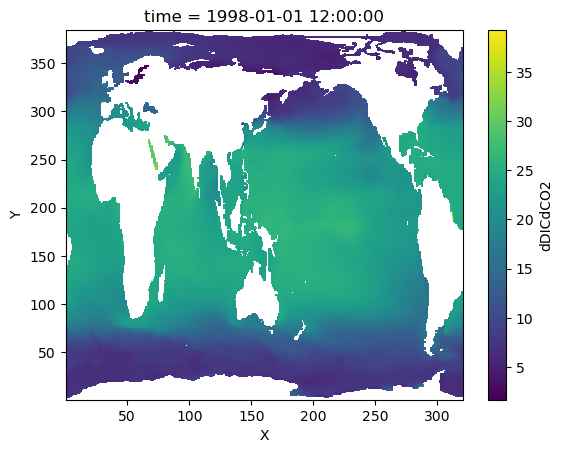

In [73]:
expanded.dDICdCO2.isel(time=0).plot()

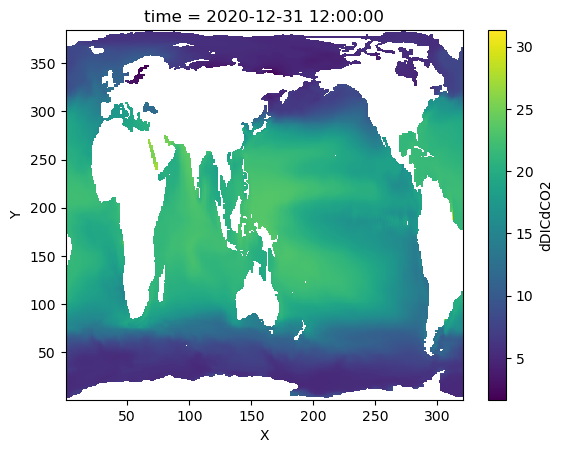

In [74]:
expanded.dDICdCO2.isel(time=-1).plot()

In [75]:
expanded

<xarray.Dataset> Size: 8GB
Dimensions:    (time: 8395, Y: 384, X: 320, d2: 2)
Coordinates:
  * Y          (Y) int32 2kB 1 2 3 4 5 6 7 8 ... 377 378 379 380 381 382 383 384
  * X          (X) int32 1kB 1 2 3 4 5 6 7 8 ... 313 314 315 316 317 318 319 320
    TLAT       (Y, X) float64 983kB ...
    TLONG      (Y, X) float64 983kB ...
  * time       (time) object 67kB 1998-01-01 12:00:00 ... 2020-12-31 12:00:00
    time_bnds  (time, d2) object 134kB 1998-01-01 00:00:00 ... 2021-01-01 00:...
Dimensions without coordinates: d2
Data variables:
    dDICdCO2   (time, Y, X) float64 8GB nan nan nan nan nan ... nan nan nan nan

In [76]:
filename = "/global/cfs/projectdirs/m4746/Projects/OAE-Efficiency-Map/data/beta/carbonate_sensitivity.nc"

In [77]:
expanded.to_netcdf(filename)